# Automatic Deep Research  - Adding coordination patterns  

## Introduction

This notebook presents a lightweight, production-ready **multi-agent research workflow built using CrewAI and executed via the CLI**. The system is designed to perform efficient, low-cost research by orchestrating specialized agents responsible for information retrieval and structured report generation. By leveraging a template-based project structure and YAML-driven configuration, the workflow ensures modularity, ease of customization, and rapid iteration while maintaining minimal token usage.


**Coordination patterns** have been introduced in the crew through a structured sequential workflow, where specialized agents collaborate via well-defined task dependencies, shared context, and output validation guardrails.

**What you'll learn:**
- How to create a crew using the CrewAI CLI
- How to design agent teams using different coordination strategies

## Background

As a research consultant, you're constantly tasked with producing comprehensive reports on diverse topics for demanding clients. You need to build an AI research crew that can rapidly gather, verify, and synthesize information from across the internet, delivering reliable, fact-checked reports that meet tight deadlines and exacting standards regardless of the subject matter.


In modern research workflows, extracting reliable insights efficiently is increasingly challenging due to the vast amount of available information and the need to balance accuracy with speed. Traditional single-agent approaches often lack structure, leading to inconsistent outputs, limited validation, and reduced reliability in the generated results.

## The solution
To address this, the workflow introduces a lightweight multi-agent system where responsibilities are clearly divided. A `Researcher agent` focuses on gathering the most relevant facts, while a `Writer agent` synthesizes this information into a concise and structured report. The process is coordinated through a sequential pipeline with task dependencies and guardrails to ensure consistency and output quality.

## Why CrewAI
CrewAI is particularly well-suited for this approach because it enables role-based agent design, structured task orchestration, and seamless integration with CLI-driven templates. This allows developers to build scalable, modular, and cost-efficient research systems while maintaining clarity, flexibility, and ease of iteration.  

## From Parallel Complexity to Efficient Sequential Research
The initial approach divided research into main and secondary topics, `executing research and fact-checking in parallel`. While this worked well in CrewAI Studio—where execution and resource management are optimized—it proved unstable in external environments (e.g., Colab) due to token limits and API constraints.

To improve reliability, the architecture was simplified from a complex, parallel multi-agent system to a lean, sequential design. The original setup introduced overhead from multiple agents, tool calls, and memory usage, leading to rate limits and inconsistent execution.

The revised workflow reduces the number of agents, limits iterations, disables memory, and constrains outputs. This streamlined design preserves core functionality—research and synthesis—while prioritizing efficiency, stability, and cost control, ensuring consistent performance within practical limits.  

The simplification isn’t a failure but it’s a `practical adjustment`:  
- It enforces token efficiency.  
- It keeps execution stable and predictable.  
- It retains the core workflow: research → synthesis → output.  

## Workflow architecture

The workflow incorporates basic coordination patterns through sequential task execution, role specialization, and context sharing between agents. While simple, this structure enables effective collaboration and lays the foundation for more advanced coordination mechanisms in future iterations.

### Workflow structure - Low-Cost Research Crew

```bash   
User Query ({user_query})
   ↓

[🔍 Researcher Agent]  
   Role: Researcher  
   Goal: Find the most important facts using minimal tokens  
   Tools:
   - EXA Search Tool (max_results=1)  
   - ScrapeWebsiteTool  

   ↓
   [Research Task]
   ← Search for the most relevant source  
   ← Extract only critical information  
   ← Return exactly 5 key facts  
   ← Each fact ≤ 20 words + 1 source  
   ↓

[📝 Writer Agent]  
   Role: Writer  
   Goal: Produce a concise, structured, and consistent report  
   Tools: None (reasoning + synthesis)

   ↓
   [Write Task]
   ← Transform facts into a short report  
   ← Ensure consistency and remove weak claims  
   ← Structure output:
        • Title  
        • Summary (≤100 words)  
        • 5 key insights  
        • Sources  
   ↓

🛡️ Output Guardrail (write_report_guardrail)  
← Validates report structure and quality  
← Ensures clarity and consistency  
   ↓

📘 Final Output  
- Concise Research Report  
- Verified Key Insights  
- Source References  
```

> _Note_ : Even in a minimal system write_report_guardrail ensures quality control, preventing:  
    - hallucinations    
    - bad formatting    
    - weak outputs  

## Set up the notebook

Begin by setting up the notebook by importing all necessary modules, and configuring the environment variables so you can connect to OpenAI.

In [1]:
pip install crewai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 967.5/967.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
pip install crewai-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 29.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: tiktoken
    Found existing installation: tiktoken 0.12.0
    Uninstalling tiktoken-0.12.0:
      Successfully uninstalled tiktoken-0.12.0
ERROR: pip's dependency resolver does n

## Using CrewAI CLI with Template-Based Development

### Advantages of Using the CLI

The [CrewAI CLI](https://docs.crewai.com/en/concepts/cli) not only simplifies execution but also accelerates development by generating a ready-to-use project structure with predefined templates. These templates provide a clear separation between agents, tasks, and crew configuration, allowing developers to quickly customize and adapt them to specific workflows. This approach reduces boilerplate code, enforces best practices, and makes it easier to maintain and scale multi-agent systems.  
The `CLI` provides a set of commands to interact with CrewAI, allowing you to create, train, run, and manage crews.

### Template-Based Workflow

When using the CLI, the typical workflow is:

1. **Generate a project template:**
   ```bash
   crewai create crew deep_research_crew
   ```  

2. **Modify the generated files:**  
- Define your agents (e.g., researcher, writer)  → Define roles, goals, tools    
- Customize tasks (research_task, write_task)  → Define task logic and expected outputs  
- Configure tools (EXA, Scraper)    
- Set execution parameters (low tokens, iterations, etc.)  → Configure execution (sequential, memory, etc.)     

3. **Run the customized crew:**
```bash
 crewai run
```

## Project structure  

The structure folder is automatically created by running the command

```bash
crewai create crew deep_research_crew
```

Follow a  couple of screenshots showing what happen in the terminal after running the command 
`crewai create crew deep_research_crew` 

- **Screenshot 1** 

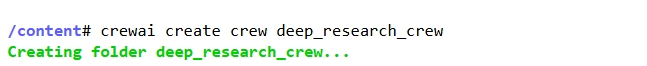

In [18]:
from IPython.display import Image, display
display(Image('/content/screenshot_terminal1.jpeg'))

- **Screenshot 2**

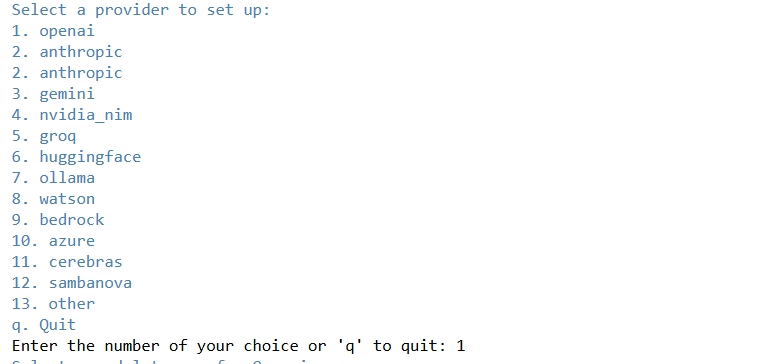

In [19]:
from IPython.display import Image, display
display(Image('/content/screenshot_terminal2.jpeg'))

- **Screenshot 3**

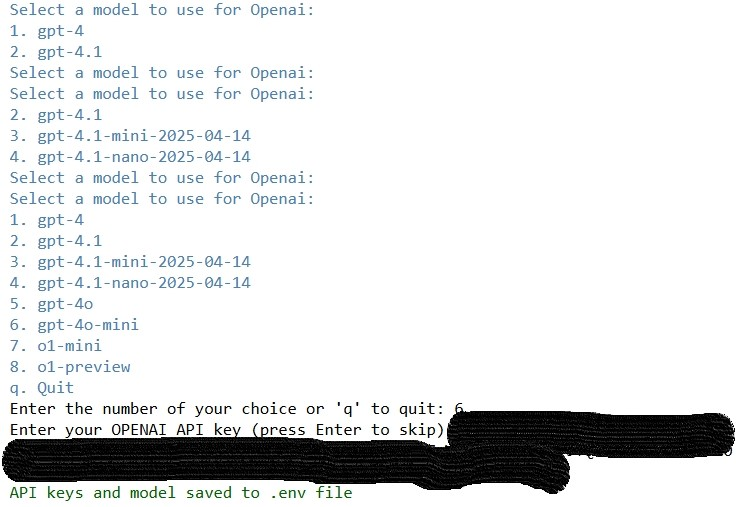

In [21]:
from IPython.display import Image, display
display(Image('/content/screenshot_terminal3.jpg'))

- **Screenshot 4**

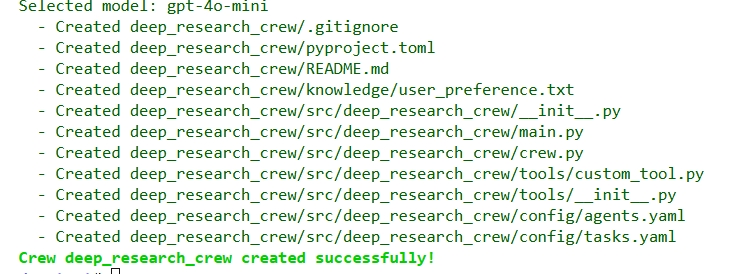

In [22]:
from IPython.display import Image, display
display(Image('/content/screenshot_terminal4.jpeg'))

This command creates finally a **template for the crew project**. See below project structure:

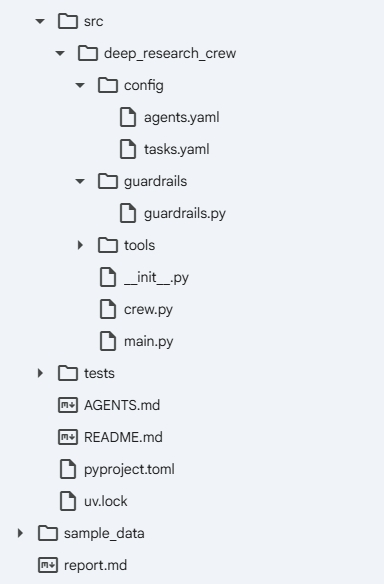

In [ ]:
from IPython.display import Image, display
display(Image('/content/repo_structure.jpeg'))

### Get familiar with the folder structure


Let's do a little walkthrough of the different files and folders:

- [`src/deep_research_crew/config`](deep_research_crew/src/deep_research_crew/config/): This folder contains the YAML configuration files for agents and tasks.
- [`src/deep_research_crew/tools`](deep_research_crew/src/deep_research_crew/tools/): You should use this folder to define custom tools if needed.
- [`src/deep_research_crew/crew.py`](deep_research_crew/src/deep_research_crew/crew.py): In this file you will define the agents and tasks, and the crew.  
- [`src/deep_research_crew/main.py`](deep_research_crew/src/deep_research_crew/main.py):  You can use this file to test the crew by replacing with the desired inputs.     
- [`src/deep_research_crew/guardrails/guardrails.py`](deep_research_crew/src/deep_research_crew/guardrails/guardrails.py): This file defines validation logic to ensure the quality and structure of the final report generated by the crew. 
- [`pyproject.toml`](deep_research_crew/pyproject.toml): This is a configuration file that defines build system requirements, dependencies, and metadata for the Python project, enabling standardized packaging and tool integration.

### Key Files to be Modified  / Defining agents, tasks, crew and guardrails   

- `src/deep_research_crew/agents.yaml` → Define roles, goals, tools  → copy the contents of the given [agents.yaml](micag2025/DeepLearningAI-CrewAI/Build_Deploy_Multi_Agents_CrewAI/Simplifed_Automatic_Deep_Research_adding_coordination_flow/config/agents.yaml)
- `src/deep_research_crew/tasks.yaml` → Define task logic and expected outputs  → copy the contents of the given [tasks.yaml](Build_Deploy_Multi_Agents_CrewAI/Simplifed_Automatic_Deep_Research_adding_coordination_flow/config/tasks.yaml)
- `src/deep_research_crew/crew.py` → Configure execution (sequential, memory, etc.)  → copy the contents of the given [crew.py](Build_Deploy_Multi_Agents_CrewAI/Simplifed_Automatic_Deep_Research_adding_coordination_flow/crew.py)
- `src/deep_research_crew/main.py` →  Set up the input query → copy the contents of the given [main.py](Build_Deploy_Multi_Agents_CrewAI/Simplifed_Automatic_Deep_Research_adding_coordination_flow/main.py)  
- `src/deep_research_crew/guardrails/guardrails.py`> set up the guradrails → copy the contents of the given [guardrails.py](Build_Deploy_Multi_Agents_CrewAI/Simplifed_Automatic_Deep_Research_adding_coordination_flow/guardrails.py)  
  

> _Note_: In the `src/deep_research_crew/crew.py` have been added the tools, thus an instance of `EXASearchTool` and a `ScrapeWebsiteTool` for the **Researcher Agent**.

##  Kickoff the crew
Go to the [src/deep_research_crew/main.py](deep_research_crew/src/deep_research_crew/main.py) file and inside the `run()` function definition replace the `inputs` with your own query. 

After  kickoff the Crew. Since you are working with the CrewAI CLI you actually need to run the code in terminal. There are two ways in which you can do this:

1.  **Option 1**   
```bash  
! cd deep_research_crew && crewai run  
```

- **Option 2**  
Execute the `crewai run` command in the `deep_research_crew` directory to run the crew
    ```bash
    cd deep_research_crew
    crewai run
    ```

In [ ]:
# run this cell to avoid warnings
import warnings
warnings.filterwarnings("ignore")

The following screenshot diplays the example of output that is diplayed in the CLI terminal after the 
process has finished. 

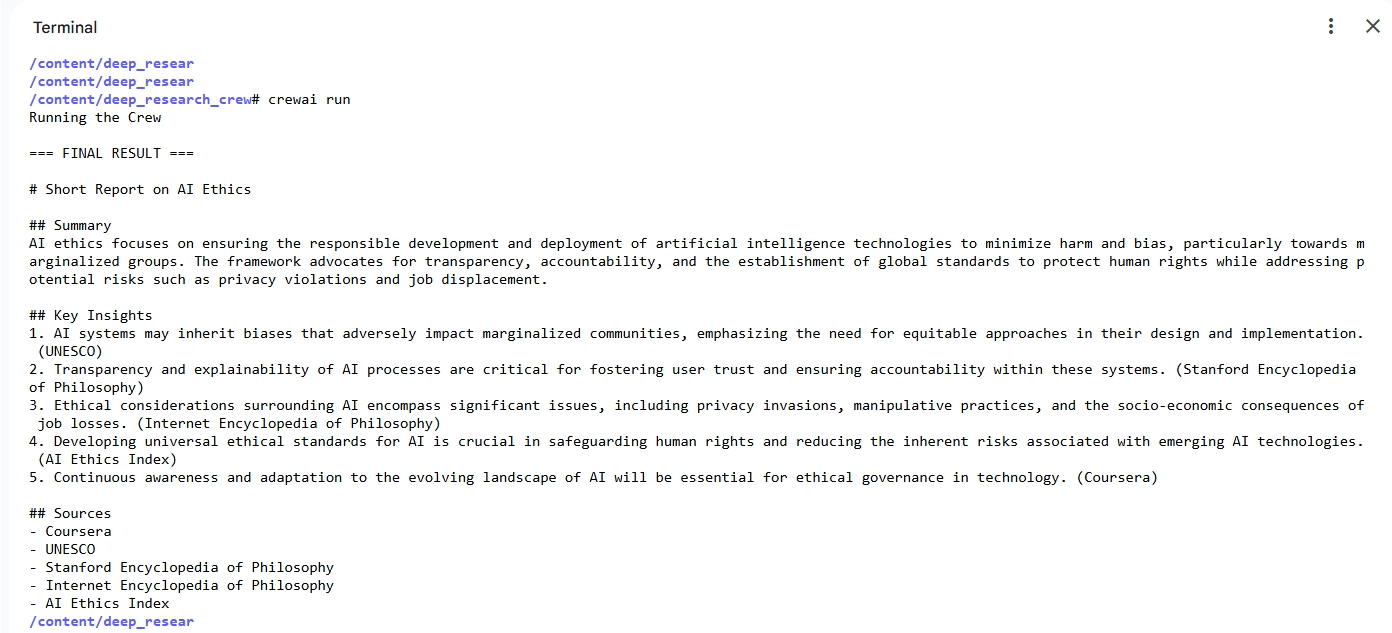

In [17]:
from IPython.display import Image, display
display(Image('/content/screenshot_terminal5.jpeg'))

#### Save Report to Markdown File  

After the application has ended to run, the file `report.md` is created, containing the report generated by the process. 

## Conclusion  

The implemented workflow demonstrates how a **simplified two-agent architecture—comprising a Researcher and a Writer—can effectively produce concise and structured research outputs**. By combining external tools for data gathering with guardrails for output validation, the system achieves a balance between efficiency and reliability. The use of the **CrewAI CLI** further enhances usability, enabling quick deployment and execution without complex setup, making this approach suitable for scalable and repeatable research tasks.

---

## Key Areas for Improvement  

- **Add a Fact-Checking Layer** : Introduce a lightweight validation agent to improve accuracy without significantly increasing token cost.

- **Enhance Source Diversity** : Increase `max_results` in the search tool to reduce reliance on a single source and improve robustness.

- **Dynamic Cost Modes** : Implement configurable modes (e.g., low-cost vs. deep research) to adapt performance based on use case.

- **Improve Guardrails** : Extend validation to include factual consistency checks and stronger formatting enforcement.

- **Introduce Memory (Optional)** : Enable selective memory for multi-step or longitudinal research scenarios.

- **CLI Automation & Integration** : Integrate the workflow into CI/CD pipelines or scheduled jobs for automated research generation.

- **Evaluation Metrics** : Add benchmarking for output quality, factual accuracy, and token efficiency.

---